In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os, json, random
from collections import Counter

I0000 00:00:1781813637.678147 2975085 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Check image path

omama_dir_path = "/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/images"
if not os.path.exists(omama_dir_path):
    print(f"File not found: {omama_dir_path}")
    print("Please update dicom_path with a valid image file path")
else:
    print(f"Found DICOM folder: {os.path.basename(omama_dir_path)}")
    omama_folder = Path("/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/images")
    IDs = sorted(str(file) for file in omama_folder.rglob("*.npz"))
    print(len(IDs))

Found DICOM folder: images
163568


In [3]:
meta_dir = Path("/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/metadata")

In [4]:
# Normalize the images
all_images = []
all_labels = []
all_ids = {}

for ID in IDs :
    meta = json.load(open(meta_dir / f"{Path(ID).stem}.json"))
    if meta["PatientID"] not in all_ids.keys() :
        all_ids[meta["PatientID"]] = 1
    else : 
        continue
    if meta["label"] == "NonCancer" :
        all_labels.append(0)
    elif meta["label"] == "Unknown" :
        continue
    elif meta["label"] == "IndexCancer" or meta["label"] == "PreIndexCancer" : 
        all_labels.append(1)
    else : 
        continue
    img = np.load(ID)['data']
    img = img.astype("float32") / 255.0 # Normalize to 0-1
    img = np.expand_dims(img, axis=-1)
    all_images.append(img)

In [5]:
# Shuffle (image, label) order
combined = list(zip(all_images, all_labels))
random.shuffle(combined)
all_images, all_labels = zip(*combined)
all_labels = np.array(all_labels, dtype=np.float32)
print(Counter(all_labels.astype(int)))

Counter({np.int64(0): 154238, np.int64(1): 2599})


In [6]:
# Create balanced dataset
nc_images = []
nc_labels = []
c_images = []
c_labels = []
NonCancer = 0
Cancer = 0
for img, label in zip(all_images, all_labels) :
    if NonCancer == 2599 and Cancer == 2599 :
        break
    if NonCancer < 2599 and label == 0 :
        nc_images.append(img)
        nc_labels.append(label)
        NonCancer += 1
    elif Cancer < 2599 and label == 1 :
        c_images.append(img)
        c_labels.append(label)
        Cancer += 1
nc_images = np.array(nc_images, dtype=np.float32)
nc_labels = np.array(nc_labels, dtype=np.float32)
c_images = np.array(c_images, dtype=np.float32)
c_labels = np.array(c_labels, dtype=np.float32)

print(Counter(nc_labels.astype(int)))
print(Counter(c_labels.astype(int)))

Counter({np.int64(0): 2599})
Counter({np.int64(1): 2599})


In [7]:
# Split data

train_size = int(0.7 * len(nc_images)) 
val_size = int(0.15 * len(nc_images))
test_size = int(0.15 * len(nc_images))

train_images = np.concatenate([nc_images[:train_size], c_images[:train_size]], axis=0)
val_images = np.concatenate([nc_images[train_size:val_size + train_size], c_images[train_size:val_size + train_size]], axis=0)
test_images = np.concatenate([nc_images[val_size + train_size:val_size + train_size + test_size], c_images[val_size + train_size:val_size + train_size + test_size]], axis=0)

train_labels = np.concatenate([nc_labels[:train_size], c_labels[:train_size]], axis=0)
val_labels = np.concatenate([nc_labels[train_size:val_size + train_size], c_labels[train_size:val_size + train_size]], axis=0)
test_labels = np.concatenate([nc_labels[val_size + train_size:val_size + train_size + test_size], c_labels[val_size + train_size:val_size + train_size + test_size]], axis=0)

print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")
print(f"Train: {len(train_labels)}, Val: {len(val_labels)}, Test: {len(test_labels)}")


Train: 3638, Val: 778, Test: 778
Train: 3638, Val: 778, Test: 778


In [8]:
print("train", Counter(train_labels.astype(int)))
print("val", Counter(val_labels.astype(int)))
print("test", Counter(test_labels.astype(int)))

train Counter({np.int64(0): 1819, np.int64(1): 1819})
val Counter({np.int64(0): 389, np.int64(1): 389})
test Counter({np.int64(0): 389, np.int64(1): 389})


In [9]:
# Check the distribution of classes
print(f'Average class probability in training set:   {train_labels.mean():.4f}')
print(f'Average class probability in validation set: {val_labels.mean():.4f}')
print(f'Average class probability in test set:       {test_labels.mean():.4f}')

Average class probability in training set:   0.5000
Average class probability in validation set: 0.5000
Average class probability in test set:       0.5000


In [10]:
# Check dimension size and color channel
print("Shape:", all_images[0].shape)

Shape: (256, 256, 1)


In [11]:
# Create the dataset and group into batches
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_ds = train_ds.shuffle(len(train_labels)).batch(32)

val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
val_ds = val_ds.batch(32)

test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels))
test_ds = test_ds.batch(32)

I0000 00:00:1781813770.580048 2975085 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38380 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:bd:00.0, compute capability: 8.0


In [12]:
# Configure dataset performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [13]:
# Import pretrained model
base_model = tf.keras.applications.EfficientNetB0(input_shape=(256, 256, 3),
                                                  include_top=False, # Don't include ImageNet classifier at the top,
                                                  weights='imagenet',
                                                 )
# Freeze base model
base_model.trainable = False

In [14]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 256, 256,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 256, 256,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 257, 257,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 128, 128,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 128,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 128, 128,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 128, 128,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 128, 128,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 128, 128,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 128, 128,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 128, 128,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [15]:
# Convert image tensor from 1 channel to 3 for the model
inputs = tf.keras.Input(shape=(256, 256, 1))
x = tf.keras.layers.Concatenate()([inputs, inputs, inputs])

# Keep base model in inference mode
x = base_model(x, training = False)
x = layers.GlobalAveragePooling2D()(x) # (batch, H, W, C) becomes (batch, C) — a single feature vector per image
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)   # add activation="sigmoid" # maps feature vectors to probability score 0-1
model = tf.keras.Model(inputs, outputs) # wrap all layers

In [16]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ input_layer_1[0]… │
│ (Concatenate)       │ 3)                │            │ input_layer_1[0]… │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 8, 8,      │  4,049,571 │ concatenate[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      1,281 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [17]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC"),
    ]
)

In [18]:
initial_epochs = 20
history = model.fit(train_ds, epochs=initial_epochs, validation_data = val_ds)

Epoch 1/20


I0000 00:00:1781813796.420984 2976941 service.cc:153] XLA service 0x7f1640069580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781813796.421016 2976941 service.cc:161]   StreamExecutor [0]: NVIDIA A100-SXM4-40GB, Compute Capability 8.0 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1781813796.663978 2976941 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781813798.194111 2976941 cuda_dnn.cc:461] Loaded cuDNN version 92302
Could not load symbol cuFuncGetName. Error: /usr/lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName
E0000 00:00:1781813801.088335 2976941 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781813805.750124 2976941 cuda_timer.cc:87] Delay kernel timed out: measured time has

  9/114 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - auc: 0.4769 - loss: 0.7092

I0000 00:00:1781813833.464841 2976941 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


113/114 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc: 0.4941 - loss: 0.6982

E0000 00:00:1781813840.155178 2976941 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781813840.593917 2976941 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781813840.871000 2976941 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781813845.600223 2976941 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781813846.784098 2976941 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000

114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - auc: 0.4941 - loss: 0.6981

E0000 00:00:1781813875.233262 2976942 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781813875.691041 2976942 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781813876.936816 2976942 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781813878.046662 2976942 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781813881.476063 2976942 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000

114/114 ━━━━━━━━━━━━━━━━━━━━ 111s 597ms/step - auc: 0.4963 - loss: 0.6971 - val_auc: 0.5000 - val_loss: 0.6943
Epoch 2/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - auc: 0.4873 - loss: 0.6979 - val_auc: 0.5154 - val_loss: 0.6932
Epoch 3/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - auc: 0.5054 - loss: 0.6980 - val_auc: 0.5000 - val_loss: 0.6962
Epoch 4/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - auc: 0.5082 - loss: 0.6974 - val_auc: 0.5013 - val_loss: 0.6969
Epoch 5/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - auc: 0.4804 - loss: 0.7022 - val_auc: 0.5013 - val_loss: 0.6937
Epoch 6/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - auc: 0.5057 - loss: 0.6963 - val_auc: 0.5000 - val_loss: 0.7037
Epoch 7/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - auc: 0.5107 - loss: 0.6976 - val_auc: 0.4987 - val_loss: 0.7087
Epoch 8/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - auc: 0.5022 - loss: 0.6985 - val_auc: 0.5000 - val_loss: 0.6940
Epoch 9/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - a

In [19]:
# See how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

Number of layers in the base model:  238


In [20]:
base_model.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = len(base_model.layers) - 30

# Unfreeze only the head layers
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

In [21]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ input_layer_1[0]… │
│ (Concatenate)       │ 3)                │            │ input_layer_1[0]… │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 8, 8,      │  4,049,571 │ concatenate[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      1,281 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,053,416 (15.46 MB)

 Trainable params: 1,497,441 (5.71 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

 Optimizer params: 2,564 (10.02 KB)

In [22]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC"),
    ],
)

In [23]:
# Train the model
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs
history_fine = model.fit(train_ds, 
                         epochs=total_epochs,       
                         initial_epoch=initial_epochs,  
                         validation_data=val_ds)

Epoch 21/30


E0000 00:00:1781814019.833915 2976942 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781814021.368557 2976942 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


113/114 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - auc_1: 0.4884 - loss: 0.7044

E0000 00:00:1781814037.223200 2976941 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781814040.932476 2976941 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


114/114 ━━━━━━━━━━━━━━━━━━━━ 59s 273ms/step - auc_1: 0.4896 - loss: 0.7014 - val_auc_1: 0.4961 - val_loss: 0.7036
Epoch 22/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - auc_1: 0.5113 - loss: 0.6960 - val_auc_1: 0.5000 - val_loss: 0.6972
Epoch 23/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - auc_1: 0.5060 - loss: 0.6968 - val_auc_1: 0.4974 - val_loss: 0.6946
Epoch 24/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - auc_1: 0.4947 - loss: 0.6984 - val_auc_1: 0.4863 - val_loss: 0.6959
Epoch 25/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - auc_1: 0.4995 - loss: 0.6971 - val_auc_1: 0.4919 - val_loss: 0.6963
Epoch 26/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - auc_1: 0.4970 - loss: 0.6994 - val_auc_1: 0.4955 - val_loss: 0.6933
Epoch 27/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - auc_1: 0.5066 - loss: 0.6956 - val_auc_1: 0.5041 - val_loss: 0.6934
Epoch 28/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - auc_1: 0.5241 - loss: 0.6938 - val_auc_1: 0.4954 - val_loss: 0.6937
Epoch 29/30
114/11

In [24]:
# Evaluate model
model.evaluate(test_ds)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc_1: 0.5585 - loss: 0.6921


[0.6921491026878357, 0.5584783554077148]

In [25]:
from sklearn.metrics import confusion_matrix

# Analyse confusion matrix
y_prob = model.predict(test_ds).reshape(-1)
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_labels.astype(int)

cm = confusion_matrix(y_true, y_pred)

25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step


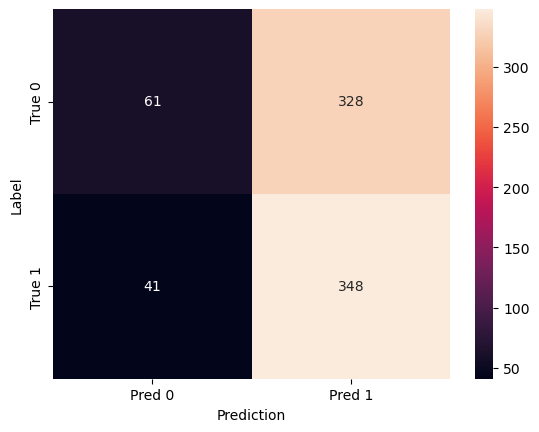

In [26]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

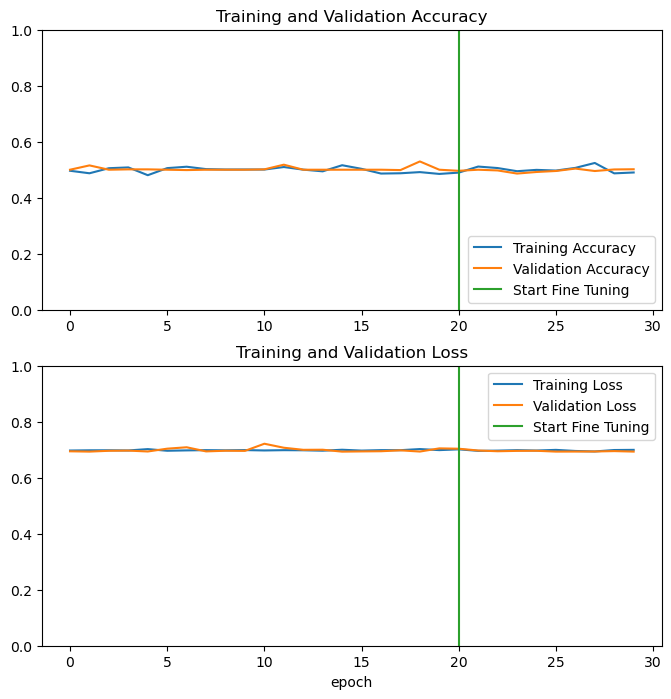

In [28]:
# Combine both for plotting
acc = history.history['auc'] + history_fine.history['auc_1']
val_acc = history.history['val_auc'] + history_fine.history['val_auc_1']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# Plot
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0, 1.0])
plt.plot([initial_epochs,initial_epochs],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs,initial_epochs],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()